## Customer Segmentation (Clustering)

#### Prepare features for clustering (RFM & StandardScaler)

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler

file_path = r"C:\Users\SKHAKH MUBASHSHIR\data.csv"

# CSV File load
df = pd.read_csv(file_path,encoding='latin-1')

#  preview check 
print("Dataset Shape:", df.shape)
df.head()

In [13]:


# Ensure Date & Revenue columns are clean
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
if "TotalRevenue" not in df.columns:
    df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

# Null CustomerIDs remove karein
df_clean = df.dropna(subset=["CustomerID", "InvoiceDate"]).copy()

# Snapshot date for Recency (latest date in dataset + 1 day)
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# RFM Feature Calculation per Customer
rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        {
            "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
            "InvoiceNo": "nunique",  # Frequency
            "TotalRevenue": "sum",  # Monetary
        }
    )
    .reset_index()
)

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Negative & zero monetary values handle karein (Negative returns/cancellations ko 0 clip karke)
rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_features["Monetary"] = rfm_features["Monetary"].clip(lower=0)
rfm_features["Recency"] = rfm_features["Recency"].clip(lower=0)

# Log Transformation
rfm_log = np.log1p(rfm_features)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("Step 1 Completed: RFM Features Cleaned, Scaled & Warning Resolved!")
print("Scaled Matrix Shape:", rfm_scaled.shape)

Step 1 Completed: RFM Features Cleaned, Scaled & Warning Resolved!
Scaled Matrix Shape: (4372, 3)


### Find Optimal K using Elbow Method

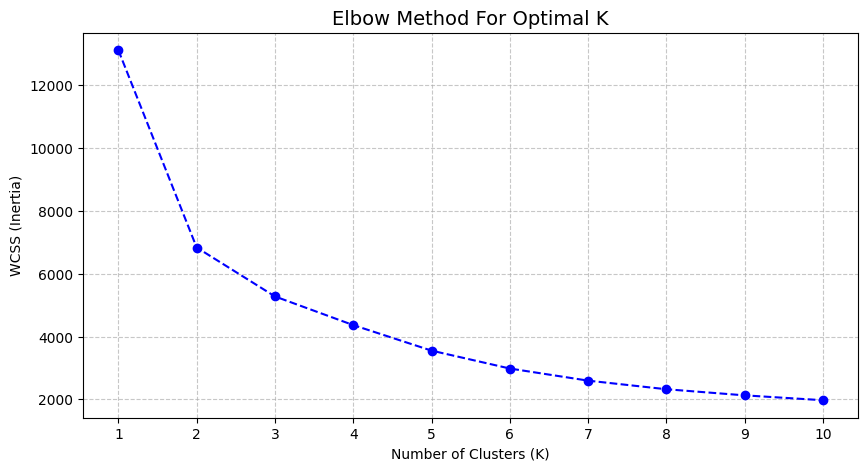

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []  # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker="o", linestyle="--", color="b")
plt.title("Elbow Method For Optimal K", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Apply K-Means Clustering

In [15]:
# Optimal K selected from Elbow Method (K = 3)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(f" Step 3 Completed: K-Means model trained with K = {optimal_k}.")
print("\nCluster Distribution:")
print(rfm["Cluster"].value_counts())

 Step 3 Completed: K-Means model trained with K = 3.

Cluster Distribution:
Cluster
1    1796
2    1759
0     817
Name: count, dtype: int64


Visualize Clusters using PCA (2D Plot)

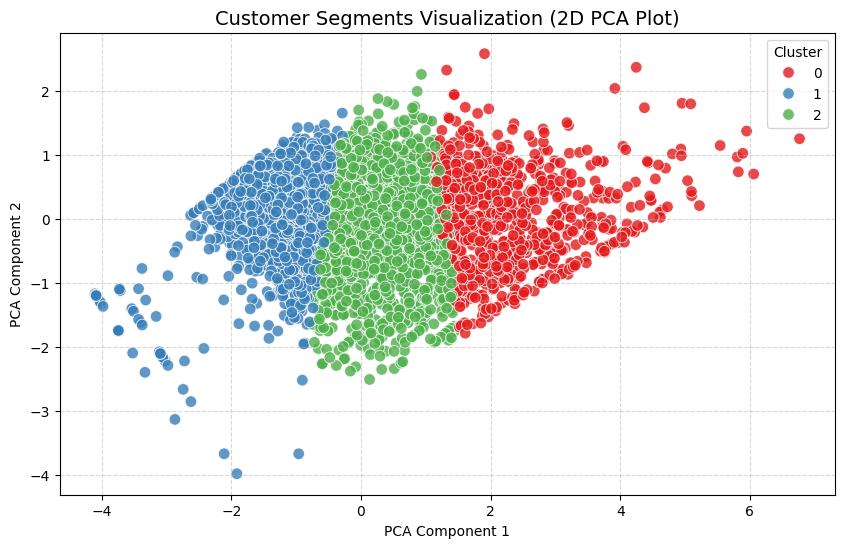

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 2D PCA Transformation
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=rfm,
    palette="Set1",
    s=70,
    alpha=0.8,
)

plt.title("Customer Segments Visualization (2D PCA Plot)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()